In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
df_awal = pd.read_csv('Youth_Risk_Behavior_Surveillance_System.csv')

print(f"Jumlah Baris : {df_awal.shape[0]:,}")
print(f"Jumlah Kolom : {df_awal.shape[1]}")

Jumlah Baris : 1,000,000
Jumlah Kolom : 20


In [6]:
df_awal.head() #melihat 5 data teratas

,Unnamed: 0,year,location,topic,sub_topic,short_question,greater_risk_question,description,greater_risk_data_value,greater_risk_low_confidence_limit,greater_risk_high_confidence_limit,lesser_risk_question,lesser_risk_data_value,lesser_risk_low_confidence_limit,lesser_risk_high_confidence_limit,sample_size,sex,race,grade,geological_location
0,1,1991,Alabama,Alcohol and Other Drug Use,Alcohol Use,Current alcohol use,Currently drank alcohol,"at least one drink of alcohol, on at least 1 d...",NaN,NaN,NaN,Did not currently drink alcohol,NaN,NaN,NaN,3,Male,American Indian or Alaska Native,11th,"(32.840571122, -86.631860762)"
1,2,1991,Alabama,Alcohol and Other Drug Use,Alcohol Use,Ever alcohol use,Ever drank alcohol,"at least one drink of alcohol, on at least 1 d...",NaN,NaN,NaN,Never drank alcohol,NaN,NaN,NaN,0,Female,Native Hawaiian or Other Pacific Islander,Total,"(32.840571122, -86.631860762)"
2,3,1991,Alabama,Alcohol and Other Drug Use,Alcohol Use,Current alcohol use,Currently drank alcohol,"at least one drink of alcohol, on at least 1 d...",NaN,NaN,NaN,Did not currently drink alcohol,NaN,NaN,NaN,2,Female,Asian,9th,"(32.840571122, -86.631860762)"
3,4,1991,Alabama,Alcohol and Other Drug Use,Alcohol Use,Ever alcohol use,Ever drank alcohol,"at least one drink of alcohol, on at least 1 d...",NaN,NaN,NaN,Never drank alcohol,NaN,NaN,NaN,0,Female,Multiple Race,Total,"(32.840571122, -86.631860762)"
4,5,1991,Alabama,Alcohol and Other Drug Use,Alcohol Use,Current alcohol use,Currently drank alcohol,"at least one drink of alcohol, on at least 1 d...",NaN,NaN,NaN,Did not currently drink alcohol,NaN,NaN,NaN,0,Male,Native Hawaiian or Other Pacific Islander,10th,"(32.840571122, -86.631860762)"


Data Wrangling

In [7]:
# Pilih kolom yang akan dianalisis saja
analisis_kolom = ['year', 'location', 'sex', 'race', 'grade',
               'greater_risk_data_value', 'sample_size', 'short_question']

df = df_awal[analisis_kolom].copy()

# Filter hanya data alkohol
df = df[df['short_question'].str.contains('alcohol', case=False, na=False)]

print(f"Data setelah filter alkohol : {len(df):,} baris")

Data setelah filter alkohol : 84,240 baris


In [8]:
# Cek missing values sebelum data wrangling (membersihkan data kotor di dataset)
print("Missing Values Sebelum Data Wrangling:")
print(df.isnull().sum())

Missing Values Sebelum Data Wrangling:
year                           0
location                       0
sex                            0
race                           0
grade                          0
greater_risk_data_value    63368
sample_size                    0
short_question                 0
dtype: int64


In [9]:
data_awal = len(df) #melihat banyak data di awal

# Menghapus baris jika kolom utama dataset yang dipakai adalah NaN
df = df.dropna(subset=['greater_risk_data_value'])

# Isi data kategorikal/teks yang NaN dengan 'Unknown', karena data tersebut tidak bisa menggunakan mean/median untuk data kategorikal/teks
for kolom in ['sex', 'race', 'grade', 'location']:
    df[kolom] = df[kolom].fillna('Unknown')
    
# Mengecek apakah ada data duplikat
df.duplicated().sum()

# Hapus duplikat
df = df.drop_duplicates()

# Konversi tipe data
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['greater_risk_data_value'] = pd.to_numeric(df['greater_risk_data_value'], errors='coerce')

print(f"Data Sebelum cleaning : {data_awal:,} baris")
print(f"Data Sesudah cleaning : {len(df):,} baris")
print(f"Data dihapus          : {data_awal - len(df):,} baris")

Data Sebelum cleaning : 84,240 baris
Data Sesudah cleaning : 20,872 baris
Data dihapus          : 63,368 baris


In [10]:
# Menyimpan dataset bersih nya 
df.to_csv("dataset_clean.csv", index=False)

In [11]:
# Mengecek ulang missing values setelah cleaning
print("Missing Values Setelah Cleaning:")
print(df.isnull().sum())

Missing Values Setelah Cleaning:
year                       0
location                   0
sex                        0
race                       0
grade                      0
greater_risk_data_value    0
sample_size                0
short_question             0
dtype: int64


In [12]:
df.head()

,year,location,sex,race,grade,greater_risk_data_value,sample_size,short_question
13,1991,Alabama,Total,White,Total,49.1,1721,Current alcohol use
15,1991,Alabama,Female,White,10th,29.0,234,Initiation of alcohol use
17,1991,Alabama,Male,White,9th,82.1,171,Ever alcohol use
19,1991,Alabama,Female,Total,12th,21.3,280,Initiation of alcohol use
24,1991,Alabama,Total,Black or African American,Total,73.8,488,Ever alcohol use


Statistik Deskriptif

In [13]:
nilai = df['greater_risk_data_value'].dropna()

mean   = nilai.mean()
median = nilai.median()
modus  = nilai.mode()[0]
min = np.min(df['greater_risk_data_value'])
max = np.max(df['greater_risk_data_value'])
range  = max - min
std_deviasi = nilai.std()
varian  = nilai.var()

print("STATISTIK DESKRIPTIF - Persentase Konsumsi Alkohol Remaja (%)")
print(f"Mean (Rata-rata)      : {mean:.2f}")
print(f"Median (Nilai Tengah) : {median:.2f}")
print(f"Modus                 : {modus:.2f}")
print(f"Minimum               : {min:.2f}")
print(f"Maksimum              : {max:.2f}")
print(f"Range                 : {range:.2f}")
print(f"Standar Deviasi       : {std_deviasi:.2f}")
print(f"Varians               : {varian:.2f}")

STATISTIK DESKRIPTIF - Persentase Konsumsi Alkohol Remaja (%)
Mean (Rata-rata)      : 46.88
Median (Nilai Tengah) : 42.50
Modus                 : 28.50
Minimum               : 0.00
Maksimum              : 97.00
Range                 : 97.00
Standar Deviasi       : 21.65
Varians               : 468.73


In [14]:
print("STATISTIK DESKRIPTIF - Berdasarkan Gender")
print(df[df['sex'] != 'Unknown'].groupby('sex')['greater_risk_data_value']
      .agg(['mean', 'median', 'std', 'count']).round(4))

STATISTIK DESKRIPTIF - Berdasarkan Gender
           mean  median      std  count
sex                                    
Female  44.5095    40.3  23.0835   6332
Male    50.7326    46.0  19.6844   6038
Total   45.9005    40.6  21.5197   8502


In [15]:
print("STATISTIK DESKRIPTIF - Berdasarkan Tingkat Kelas")
print(df[df['grade'] != 'Unknown'].groupby('grade')['greater_risk_data_value']
      .agg(['mean', 'median', 'std', 'count']).round(4))

STATISTIK DESKRIPTIF - Berdasarkan Tingkat Kelas
          mean  median      std  count
grade                                 
10th   47.5798   42.75  20.5909   3774
11th   47.5695   43.60  23.2222   3586
12th   48.1380   45.50  25.7147   3426
9th    47.3364   43.50  17.1326   3821
Total  45.0854   39.90  21.2698   6265


In [16]:
print("STATISTIK DESKRIPTIF - Berdasarkan Ras")
print(df[df['race'] != 'Unknown'].groupby('race')['greater_risk_data_value']
      .agg(['mean', 'median', 'std', 'count']).round(4))

STATISTIK DESKRIPTIF - Berdasarkan Ras
                                              mean  median      std  count
race                                                                      
American Indian or Alaska Native           55.9485   48.00  20.6403     68
Asian                                      35.6256   29.75  17.6433    574
Black or African American                  42.3270   37.20  20.6122   3013
Hispanic or Latino                         50.2095   45.60  21.5001   1821
Multiple Race                              51.4125   46.00  18.5601     64
Native Hawaiian or Other Pacific Islander  44.9988   40.80  20.5433    165
Total                                      46.3620   42.00  21.3886   9317
White                                      50.0030   47.00  22.1892   5850


Skewness dan Kurtosis

In [17]:
# skewness dan kurtosis
skewness = df['greater_risk_data_value'].skew()
kurtosis = df['greater_risk_data_value'].kurt()

print("BENTUK DISTRIBUSI DATA - Persentase Konsumsi Alkohol")
print(f"Skewness : {skewness:.2f}")
print(f"Kurtosis : {kurtosis:.2f}")

if skewness > 0.5:
    print("-> Distribusi menceng kanan (positif skew)")
elif skewness < -0.5:
    print("-> Distribusi menceng kiri (negatif skew)")
else:
    print("-> Distribusi relatif simetris")

if kurtosis > 0:
    print("-> Leptokurtik (lebih lancip dari normal)")
elif kurtosis < 0:
    print("-> Platikurtik (lebih datar dari normal)")
else:
    print("-> Mesokurtik (sama seperti normal)")

BENTUK DISTRIBUSI DATA - Persentase Konsumsi Alkohol
Skewness : 0.40
Kurtosis : -0.99
-> Distribusi relatif simetris
-> Platikurtik (lebih datar dari normal)


In [18]:
print("SKEWNESS DAN KURTOSIS - Berdasarkan Gender")
for gender, group in df[df['sex'].isin(['Male', 'Female'])].groupby('sex'):
    s = group['greater_risk_data_value'].skew()
    k = group['greater_risk_data_value'].kurt()
    print(f"\n  {gender}")
    print(f"  Skewness : {s:.4f}")
    print(f"  Kurtosis : {k:.4f}")
    if s > 0.5:
        print("  -> Distribusi menceng kanan (positif skew)")
    elif s < -0.5:
        print("  -> Distribusi menceng kiri (negatif skew)")
    else:
        print("  -> Distribusi relatif simetris")
    if k > 0:
        print("  -> Leptokurtik (lebih lancip dari normal)")
    elif k < 0:
        print("  -> Platikurtik (lebih datar dari normal)")
    else:
        print("  -> Mesokurtik (sama seperti normal)")

SKEWNESS DAN KURTOSIS - Berdasarkan Gender

  Female
  Skewness : 0.4099
  Kurtosis : -1.0624
  -> Distribusi relatif simetris
  -> Platikurtik (lebih datar dari normal)

  Male
  Skewness : 0.3989
  Kurtosis : -0.9602
  -> Distribusi relatif simetris
  -> Platikurtik (lebih datar dari normal)


Statistik Inferensial : Uji Chi-Square

In [19]:
# Buat kolom kategori: Tinggi / Rendah berdasarkan nilai median
median_val2 = df['greater_risk_data_value'].median()
df['alcohol_cat'] = df['greater_risk_data_value'].apply(
    lambda x: 'Tinggi' if x >= median_val2 else 'Rendah'
)

print(f"Median threshold : {median_val2:.2f}%")
print(df['alcohol_cat'].value_counts())

Median threshold : 42.50%
alcohol_cat
Tinggi    10455
Rendah    10417
Name: count, dtype: int64


In [20]:
# UJI CHI-SQUARE 1: Gender vs Konsumsi Alkohol
subset = df[df['sex'] != 'Unknown'][['sex', 'alcohol_cat']].dropna()
tabel_sex = pd.crosstab(subset['sex'], subset['alcohol_cat'])
chi2_sex, p_sex, dof_sex, _ = stats.chi2_contingency(tabel_sex)

print("UJI CHI-SQUARE: Gender vs Konsumsi Alkohol")
print("\nTabel Kontingensi:")
print(tabel_sex)
print(f"\nChi-Square : {chi2_sex:.4f}")
print(f"P-value    : {p_sex:.6f}")
print(f"Df         : {dof_sex}")
if p_sex < 0.05:
    print("-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara gender dan konsumsi alkohol")
else:
    print("-> P-value > 0.05: Tidak terdapat hubungan signifikan antara gender dan konsumsi alkohol")

UJI CHI-SQUARE: Gender vs Konsumsi Alkohol

Tabel Kontingensi:
alcohol_cat  Rendah  Tinggi
sex                        
Female         3396    2936
Male           2527    3511
Total          4494    4008

Chi-Square : 221.4907
P-value    : 0.000000
Df         : 2
-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara gender dan konsumsi alkohol


In [21]:
# UJI CHI-SQUARE 2: Tingkat Kelas vs Konsumsi Alkohol
subset = df[df['grade'] != 'Unknown'][['grade', 'alcohol_cat']].dropna()
tabel_grade = pd.crosstab(subset['grade'], subset['alcohol_cat'])
chi2_grade, p_grade, dof_grade, _ = stats.chi2_contingency(tabel_grade)

print("UJI CHI-SQUARE: Tingkat Kelas vs Konsumsi Alkohol")
print("\nTabel Kontingensi:")
print(tabel_grade)
print(f"\nChi-Square : {chi2_grade:.4f}")
print(f"P-value    : {p_grade:.6f}")
print(f"Df         : {dof_grade}")
if p_grade < 0.05:
    print("-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara tingkat kelas dan konsumsi alkohol")
else:
    print("-> P-value > 0.05: Tidak terdapat hubungan signifikan antara tingkat kelas dan konsumsi alkohol")

UJI CHI-SQUARE: Tingkat Kelas vs Konsumsi Alkohol

Tabel Kontingensi:
alcohol_cat  Rendah  Tinggi
grade                      
10th           1864    1910
11th           1744    1842
12th           1622    1804
9th            1779    2042
Total          3408    2857

Chi-Square : 79.4006
P-value    : 0.000000
Df         : 4
-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara tingkat kelas dan konsumsi alkohol


In [22]:
# UJI CHI-SQUARE 3: Ras vs Konsumsi Alkohol
subset = df[df['race'] != 'Unknown'][['race', 'alcohol_cat']].dropna()
tabel_race = pd.crosstab(subset['race'], subset['alcohol_cat'])
chi2_race, p_race, dof_race, _ = stats.chi2_contingency(tabel_race)

print("UJI CHI-SQUARE: Ras vs Konsumsi Alkohol")
print("\nTabel Kontingensi:")
print(tabel_race)
print(f"\nChi-Square : {chi2_race:.4f}")
print(f"P-value    : {p_race:.6f}")
print(f"Df         : {dof_race}")
if p_race < 0.05:
    print("-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara ras dan konsumsi alkohol")
else:
    print("-> P-value > 0.05: Tidak terdapat hubungan signifikan antara ras dan konsumsi alkohol")

UJI CHI-SQUARE: Ras vs Konsumsi Alkohol

Tabel Kontingensi:
alcohol_cat                                Rendah  Tinggi
race                                                     
American Indian or Alaska Native               21      47
Asian                                         401     173
Black or African American                    1867    1146
Hispanic or Latino                            777    1044
Multiple Race                                  26      38
Native Hawaiian or Other Pacific Islander      90      75
Total                                        4737    4580
White                                        2498    3352

Chi-Square : 443.0475
P-value    : 0.000000
Df         : 7
-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara ras dan konsumsi alkohol


In [23]:
# UJI CHI-SQUARE 4: Wilayah vs Konsumsi Alkohol
subset = df[df['location'] != 'Unknown'][['location', 'alcohol_cat']].dropna()
tabel_loc = pd.crosstab(subset['location'], subset['alcohol_cat'])
chi2_loc, p_loc, dof_loc, _ = stats.chi2_contingency(tabel_loc)

print("UJI CHI-SQUARE: Wilayah vs Konsumsi Alkohol")
print("\nTabel Kontingensi (10 wilayah pertama):")
print(tabel_loc.head(10))
print(f"\nChi-Square : {chi2_loc:.4f}")
print(f"P-value    : {p_loc:.6f}")
print(f"Df         : {dof_loc}")
if p_loc < 0.05:
    print("-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara wilayah dan konsumsi alkohol")
else:
    print("-> P-value > 0.05: Tidak terdapat hubungan signifikan antara wilayah dan konsumsi alkohol")

UJI CHI-SQUARE: Wilayah vs Konsumsi Alkohol

Tabel Kontingensi (10 wilayah pertama):
alcohol_cat         Rendah  Tinggi
location                          
Alabama                286     417
Alaska                  37      63
American Samoa         175      82
Arkansas               195     262
Boston, MA             270     185
Broward County, FL     321     328
Chicago, IL            370     244
Connecticut             49      56
Dallas, TX             393     440
Delaware               143     129

Chi-Square : 794.5917
P-value    : 0.000000
Df         : 58
-> P-value < 0.05: Terdapat hubungan SIGNIFIKAN antara wilayah dan konsumsi alkohol


Visualisasi Data

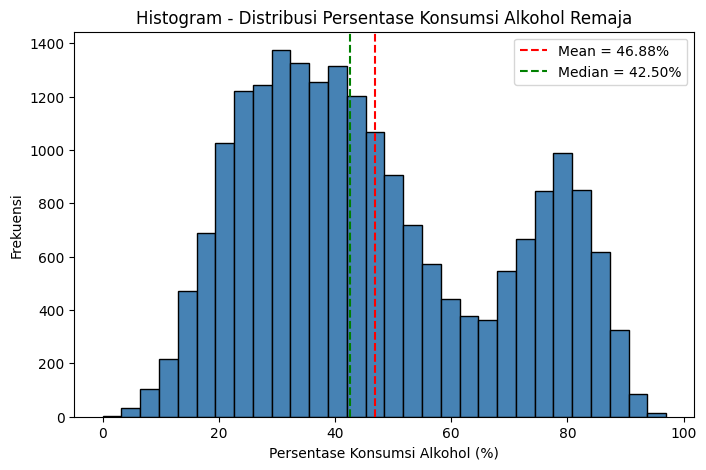

In [24]:
# Histogram Distribusi Persentase Konsumsi Alkohol Remaja
plt.figure(figsize=(8, 5))
plt.hist(df['greater_risk_data_value'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}%')
plt.axvline(median, color='green', linestyle='--', label=f'Median = {median:.2f}%')
plt.title("Histogram - Distribusi Persentase Konsumsi Alkohol Remaja")
plt.xlabel("Persentase Konsumsi Alkohol (%)")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

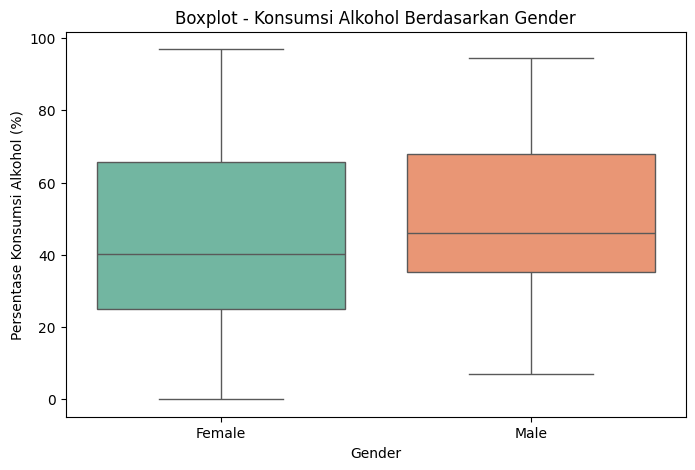

In [25]:
# Boxplot Konsumsi Alkohol Berdasarkan Gender
data_sex = df[df['sex'].isin(['Male', 'Female'])]

plt.figure(figsize=(8, 5))
sns.boxplot(data=data_sex, hue='sex', x='sex', y='greater_risk_data_value', palette='Set2', legend=False)
plt.title("Boxplot - Konsumsi Alkohol Berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Persentase Konsumsi Alkohol (%)")
plt.show()

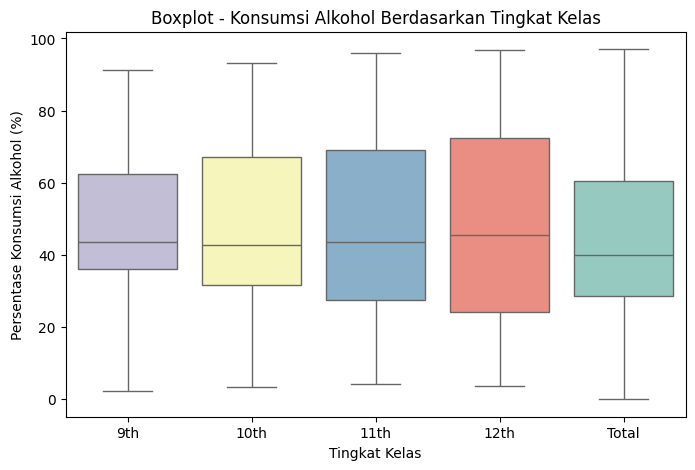

In [26]:
# Boxplot Konsumsi Alkohol Berdasarkan Tingkat Kelas
grade_order = ['9th', '10th', '11th', '12th', 'Total']
grade_available = [g for g in grade_order if g in df['grade'].unique()]
data_grade = df[df['grade'].isin(grade_available)]

plt.figure(figsize=(8, 5))
sns.boxplot(data=data_grade, hue = 'grade', x='grade', y='greater_risk_data_value',
            order=grade_available, palette='Set3')
plt.title("Boxplot - Konsumsi Alkohol Berdasarkan Tingkat Kelas")
plt.xlabel("Tingkat Kelas")
plt.ylabel("Persentase Konsumsi Alkohol (%)")
plt.show()

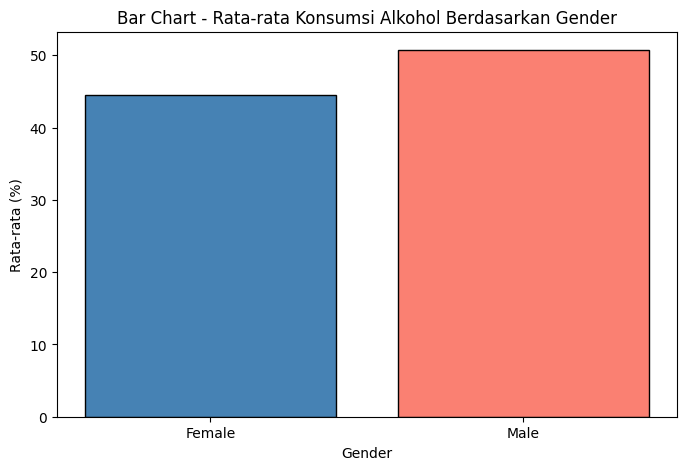

In [27]:
# Bar Chart Rata-rata Konsumsi Alkohol Berdasarkan Gender
avg_sex = df[df['sex'].isin(['Male', 'Female'])].groupby('sex')['greater_risk_data_value'].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_sex.index, avg_sex.values, color=['steelblue', 'salmon'], edgecolor='black')
plt.title("Bar Chart - Rata-rata Konsumsi Alkohol Berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Rata-rata (%)")
plt.show()

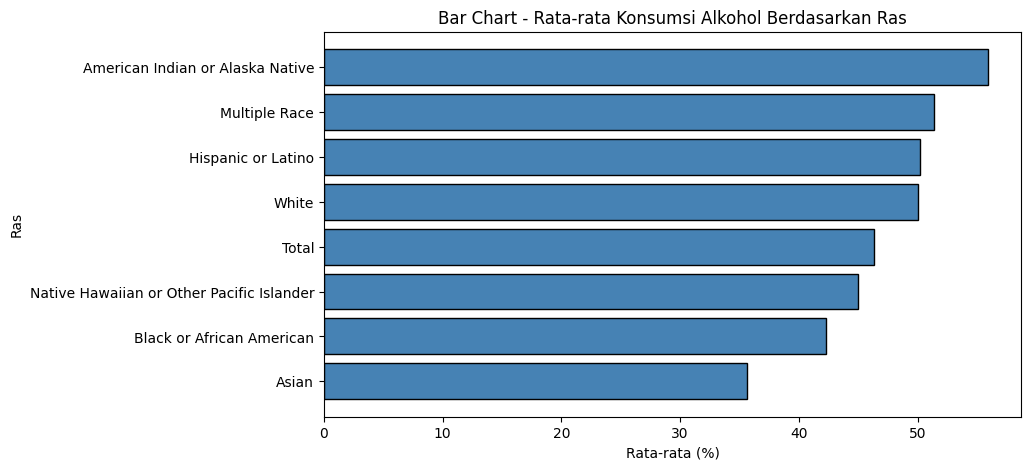

In [28]:
# Bar Chart Rata-rata Konsumsi Alkohol Berdasarkan Gender
avg_race = df[df['race'] != 'Unknown'].groupby('race')['greater_risk_data_value'].mean().sort_values()

plt.figure(figsize=(9, 5))
plt.barh(avg_race.index, avg_race.values, color='steelblue', edgecolor='black')
plt.title("Bar Chart - Rata-rata Konsumsi Alkohol Berdasarkan Ras")
plt.xlabel("Rata-rata (%)")
plt.ylabel("Ras")
plt.show()

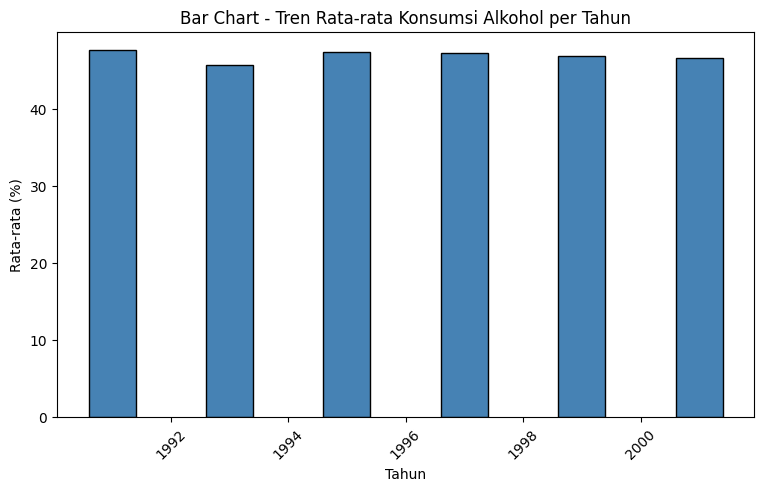

In [29]:
# Bar Chart Tren Rata-rata Konsumsi Alkohol per Tahun
avg_year = df.groupby('year')['greater_risk_data_value'].mean()

plt.figure(figsize=(9, 5))
plt.bar(avg_year.index, avg_year.values, color='steelblue', edgecolor='black')
plt.title("Bar Chart - Tren Rata-rata Konsumsi Alkohol per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata (%)")
plt.xticks(rotation=45)
plt.show()